# 컴퓨터 비전  

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용 

In [1]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 머신러닝 맛보기

## 예제1)

### 모델 기반 학습의 예시로 1인당 GDP데이터로 더 나은 삶의 지표(Better Life Index) 예측

#### OECD 웹사이트에서 더 나은 삶의 지표(Better Life Index) 데이터 
#### IMF 웹사이트에서 1인당 GDP 통계데이터 
#### 두 데이터 테이블을 합치고 1인당 GDP로 정렬 

In [2]:
# CSV 파일로 읽어오기 

import pandas as pd
import os

country_stats = pd.read_csv(os.getcwd()+'/country_stats.csv')    # CSV 파일 읽기 
country_stats

,Country,GDP per capita,Life satisfaction
0,Russia,9054.914,6.0
1,Turkey,9437.372,5.6
2,Hungary,12239.894,4.9
3,Poland,12495.334,5.8
4,Slovak Republic,15991.736,6.1
5,Estonia,17288.083,5.6
6,Greece,18064.288,4.8
7,Portugal,19121.592,5.1
8,Slovenia,20732.482,5.7
9,Spain,25864.721,6.5


In [3]:
import numpy as np 

X = np.c_[country_stats["GDP per capita"]] 
print("X=", X)
print("-" * 10)
y = np.c_[country_stats["Life satisfaction"]]
print("y=", y)

X= [[ 9054.914]
 [ 9437.372]
 [12239.894]
 [12495.334]
 [15991.736]
 [17288.083]
 [18064.288]
 [19121.592]
 [20732.482]
 [25864.721]
 [27195.197]
 [29866.581]
 [32485.545]
 [35343.336]
 [37044.891]
 [37675.006]
 [40106.632]
 [40996.511]
 [41973.988]
 [43331.961]
 [43603.115]
 [43724.031]
 [43770.688]
 [49866.266]
 [50854.583]
 [50961.865]
 [51350.744]
 [52114.165]
 [55805.204]]
----------
y= [[6. ]
 [5.6]
 [4.9]
 [5.8]
 [6.1]
 [5.6]
 [4.8]
 [5.1]
 [5.7]
 [6.5]
 [5.8]
 [6. ]
 [5.9]
 [7.4]
 [7.3]
 [6.5]
 [6.9]
 [7. ]
 [7.4]
 [7.3]
 [7.3]
 [6.9]
 [6.8]
 [7.2]
 [7.5]
 [7.3]
 [7. ]
 [7.5]
 [7.2]]


###  위 데이터(x, y)를 보기 편하게 시각화 하면 다음과 같이 나타난다.

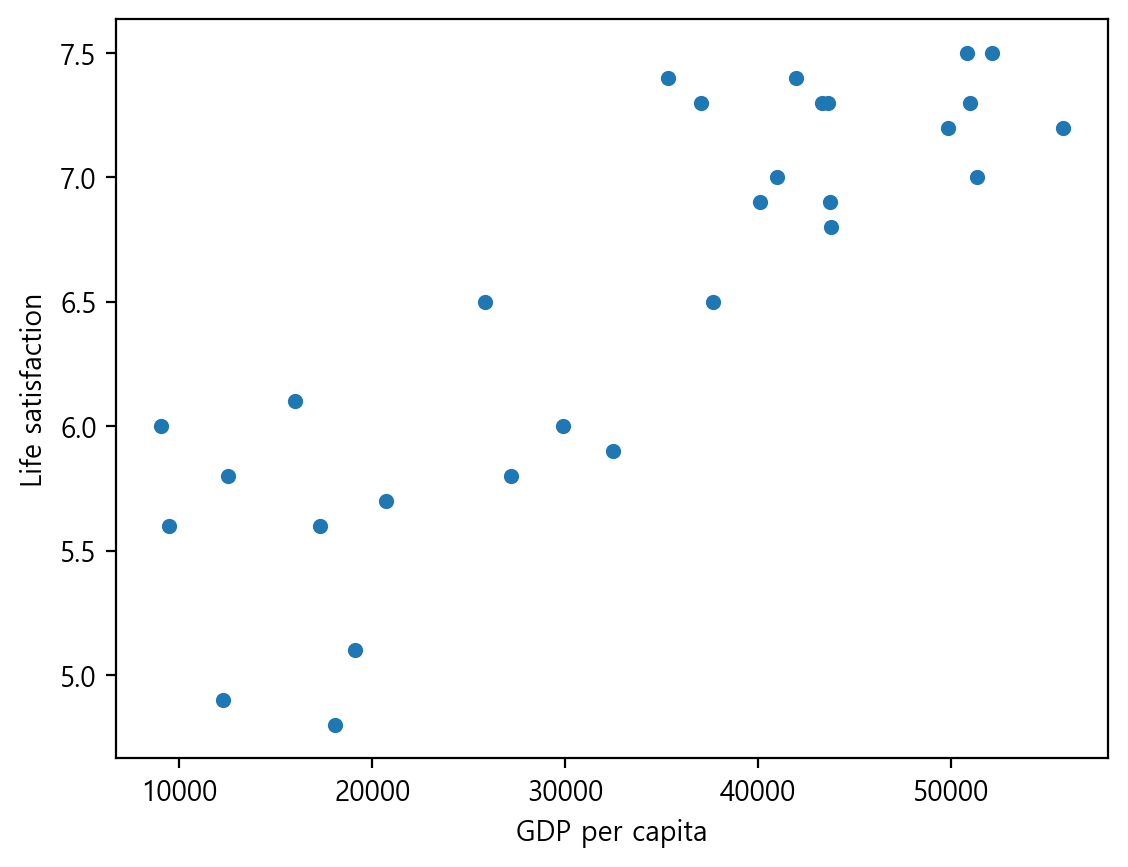

In [5]:
# 데이터 시각화

import matplotlib.pyplot as plt

country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

### 선형회귀 모델

In [ ]:
# 삶의 만족도는 국가의 1인당 GDP가 증가할수록 거의 선형으로 상승하는 것을 확인할 수 있다. 
# 그러므로, 1인당 GDP의 선형 함수로 삶의 만족도를 모델링 해보자. 
# 이 단계를 모델 선택(Model Selection)이라고 한다.
# 1인당 GDP라는 특성 하나를 가진 삶의 만족도에 대한 선형 모델(Linear Model)이다.

In [6]:
import sklearn.linear_model

model = sklearn.linear_model.LinearRegression() # 선형 모델 선택 . 선형 회귀 모델
model.fit(X, y) # 모델 훈련

print("intercept=", model.intercept_)     # intercept= [4.8530528]
print("coef=", model.coef_)               # coef= [[4.91154459e-05]]

intercept= [4.8530528]
coef= [[4.91154459e-05]]


In [7]:
X_new = [[22587]] # 키프로스 1인당 GDP
print("Predict=", model.predict(X_new)) # 키프로스에 대한 예측 출력 [[ 5.96242338]]

Predict= [[5.96242338]]


### k-최근접 이웃 모델

### k=3 일때, 키프로와 가장 가까운 슬로베니아, 포르투갈, 스페인의 삶의 만족도를 평균한다. 

In [8]:
import sklearn.neighbors

knn = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)  # 모델 선택 , k-최근접 이웃 모델 생성
knn.fit(X, y)                                               # 모델 훈련 

# 키프로스에 대한 예측    
print(knn.predict(X_new))  # [[5.76666667]]

[[5.76666667]]
